# Science Aggregator — Data Pipeline & EDA

**Source:** [gisnauka.ru](https://gisnauka.ru) — Russian NIOKTR (R&D) registry  
**Raw data:** 6 JSON files, 2020–2025  
**Result:** 104,466 projects · 34 columns · Parquet

In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RAW_DIR        = Path('../data/raw')
PROCESSED_FILE = Path('../data/processed/clean_all_years.parquet')

## 1. Raw data structure

Each JSON file has 43 fields. After `pd.json_normalize` expands nested dicts (`executor`, `customer`, `work_supervisor`, `organization_supervisor`) we get **87 columns** — most of which need to be cleaned or dropped.

In [6]:
# Load one file to inspect the raw structure
sample_file = sorted(RAW_DIR.glob('*.json'))[0]
with open(sample_file, 'r', encoding='utf-8') as f:
    raw = json.load(f)
cards = raw.get('cards', raw)

print(f'File    : {sample_file.name}')
print(f'Records : {len(cards):,}')
print(f'Fields  : {len(cards[0])} in raw JSON')
print()
print(f'  {"field":<50} type')
print(f'  {"-"*60}')
for k, v in cards[0].items():
    t = f'list[{len(v)}]' if isinstance(v, list) else type(v).__name__
    print(f'  {k:<50} {t}')

File    : open_data_nioktr_2020_all_months.json
Records : 18,198
Fields  : 43 in raw JSON

  field                                              type
  ------------------------------------------------------------
  registration_number                                str
  created_date                                       str
  name                                               str
  annotation                                         str
  keyword_list                                       list[1]
  start_date                                         str
  end_date                                           str
  contract_number                                    str
  contract_date                                      str
  federal_program                                    NoneType
  state_program                                      str
  interstate_target_program                          NoneType
  nioktr_types                                       list[1]
  nioktr_bases               

In [7]:
# Concrete examples of why flattening is needed
r = cards[0]

print('keyword_list — list of strings -> join with ";"')
print(f'  before : {r["keyword_list"]}')
print(f'  after  : {"; ".join(r["keyword_list"])}')
print()

print('budgets — list of dicts -> sum all funds')
for b in r['budgets'][:2]:
    print(f'  {b}')
total = sum(float(b.get('funds', 0) or 0) for b in r['budgets'])
print(f'  -> budget_total_thousands = {total:,.1f}')
print()

print('stages — list -> count')
print(f'  {len(r["stages"])} stages -> stages_count = {len(r["stages"])}')
print()

print('work_supervisor — dict -> single full name field')
ws = r['work_supervisor']
print(f'  before : {ws}')
print(f'  after  : {ws["surname"]} {ws["name"]} {ws["patronymic"]}')

keyword_list — list of strings -> join with ";"
  before : ['Индекс активного долголетия (ИАД), ИАД Субъект, ИАД РФ, проект системы весов (весовых коэффициентов), Национальные веса, Региональные веса, статистическая надежность']
  after  : Индекс активного долголетия (ИАД), ИАД Субъект, ИАД РФ, проект системы весов (весовых коэффициентов), Национальные веса, Региональные веса, статистическая надежность

budgets — list of dicts -> sum all funds
  {'funds': '2500.000', 'kbk': '15701121590592020241', 'budget_type': 'Средства федерального бюджета'}
  -> budget_total_thousands = 2,500.0

stages — list -> count
  1 stages -> stages_count = 1

work_supervisor — dict -> single full name field
  before : {'name': None, 'surname': 'Синявская О.В.', 'patronymic': None, 'position': 'Заместитель директора института', 'degree': 'Кандидат экономических наук', 'rank': None, 'wos_research_id': None, 'scopus_author_id': None, 'rinc_id': None, 'url': None, 'orcid': None, 'territory': None}
  after  : Син

## 2. Load all files

In [8]:
files = sorted(RAW_DIR.glob('*.json'))
dfs = []

for file in files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    cards = data.get('cards', data) if isinstance(data, dict) else data
    df = pd.json_normalize(cards)
    dfs.append(df)
    print(f'  {file.name}: {len(df):,} records')

raw_df = pd.concat(dfs, ignore_index=True)
print(f'\nCombined: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns')

  open_data_nioktr_2020_all_months.json: 18,198 records
  open_data_nioktr_2021_all_months.json: 16,550 records
  open_data_nioktr_2022_all_months.json: 25,934 records
  open_data_nioktr_2023_all_months.json: 19,188 records
  open_data_nioktr_2024_all_months.json: 15,745 records
  open_data_nioktr_2025_all_months.json: 16,590 records

Combined: 112,205 rows x 92 columns


## 3. Deduplication

The same project appears in multiple yearly snapshots. We deduplicate by `registration_number`, keeping `last` — the most recently downloaded version.

Total rows      : 112,205
Duplicates      : 7,739  (6.9%)
Unique projects : 104,466


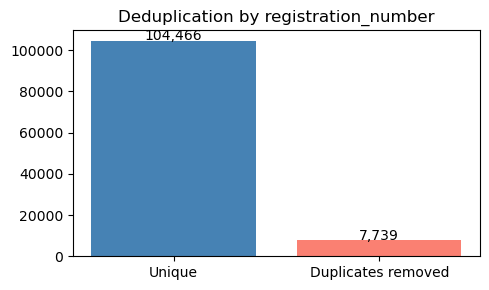

In [9]:
dupes  = raw_df['registration_number'].duplicated().sum()
unique = len(raw_df) - dupes

print(f'Total rows      : {len(raw_df):,}')
print(f'Duplicates      : {dupes:,}  ({dupes/len(raw_df)*100:.1f}%)')
print(f'Unique projects : {unique:,}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Unique', 'Duplicates removed'], [unique, dupes], color=['steelblue', 'salmon'])
ax.set_title('Deduplication by registration_number')
for i, v in enumerate([unique, dupes]):
    ax.text(i, v + 300, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

## 4. Column fill rate

Fill rate computed on the full 112k dataset (before dedup) — more representative.  
Columns below 30% are dropped automatically. `scientific_groundwork` (76%) is dropped manually — it's a large text blob, useless for aggregation but reserved for RAG in Checkpoint 2.

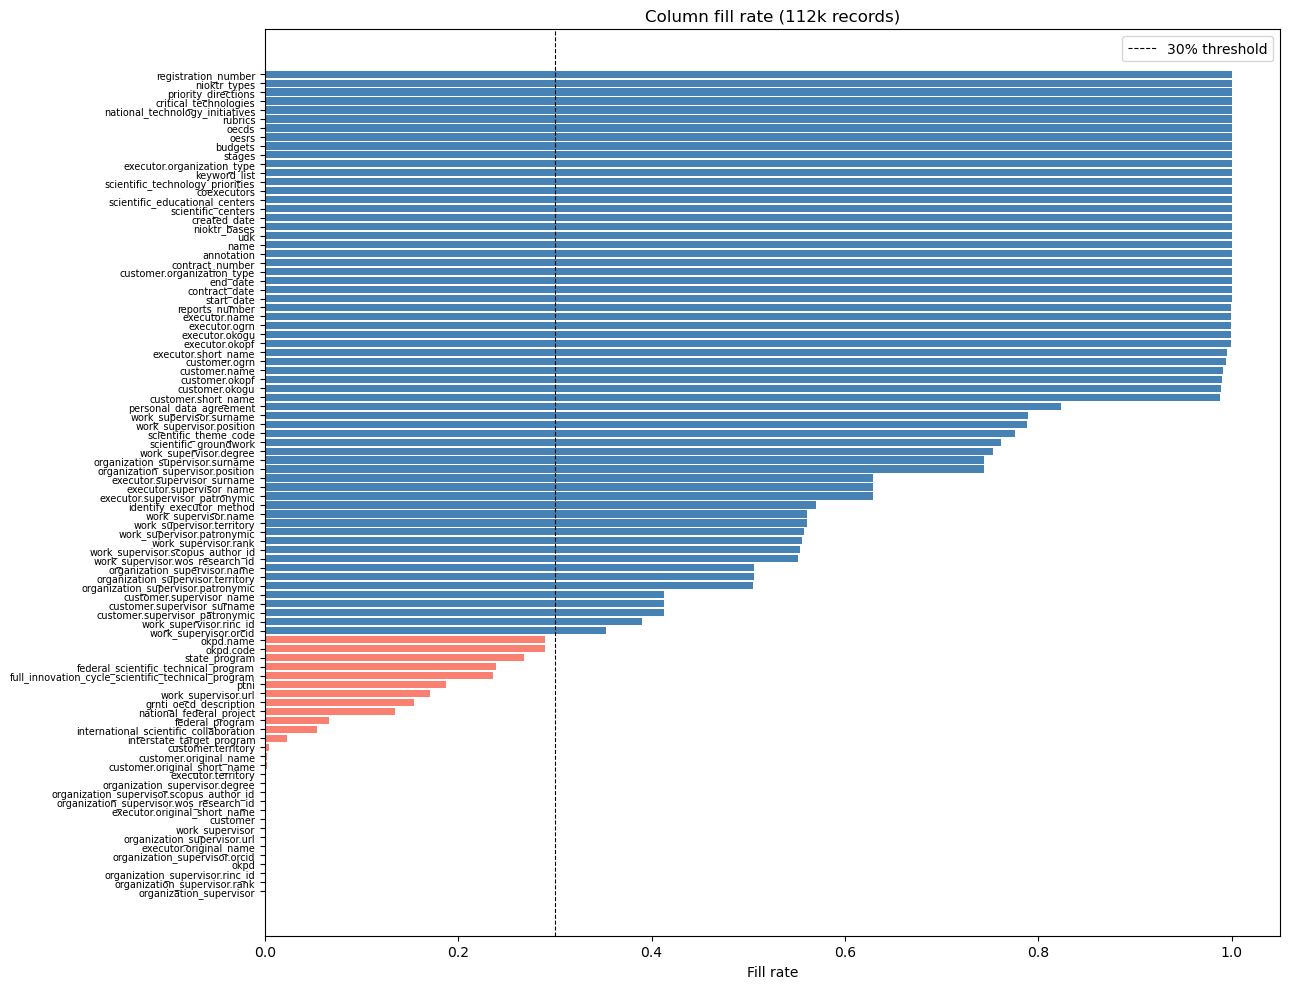

Auto-dropped (29 columns):
    0%  organization_supervisor
    0%  organization_supervisor.rank
    0%  organization_supervisor.rinc_id
    0%  okpd
    0%  organization_supervisor.orcid
    0%  executor.original_name
    0%  organization_supervisor.url
    0%  work_supervisor
    0%  customer
    0%  executor.original_short_name
    0%  organization_supervisor.wos_research_id
    0%  organization_supervisor.scopus_author_id
    0%  organization_supervisor.degree
    0%  executor.territory
    0%  customer.original_short_name
    0%  customer.original_name
    0%  customer.territory
    2%  interstate_target_program
    5%  international_scientific_collaboration
    7%  federal_program
   13%  national_federal_project
   15%  grnti_oecd_description
   17%  work_supervisor.url
   19%  ptni
   24%  full_innovation_cycle_scientific_technical_program
   24%  federal_scientific_technical_program
   27%  state_program
   29%  okpd.code
   29%  okpd.name


In [10]:
fill_rate = raw_df.notna().mean().sort_values()

fig, ax = plt.subplots(figsize=(13, 10))
colors = ['salmon' if v < 0.3 else 'steelblue' for v in fill_rate.values]
ax.barh(range(len(fill_rate)), fill_rate.values, color=colors)
ax.axvline(x=0.3, color='black', linestyle='--', linewidth=0.8, label='30% threshold')
ax.set_yticks(range(len(fill_rate)))
ax.set_yticklabels(fill_rate.index, fontsize=7)
ax.set_xlabel('Fill rate')
ax.set_title('Column fill rate (112k records)')
ax.legend()
plt.tight_layout()
plt.show()

dropped = fill_rate[fill_rate < 0.3]
print(f'Auto-dropped ({len(dropped)} columns):')
for col, val in dropped.items():
    print(f'  {val:4.0%}  {col}')

## 5. Clean dataset

In [11]:
df = pd.read_parquet(PROCESSED_FILE)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print(f'  {"column":<40} fill rate')
print(f'  {"-"*52}')
for col, val in df.notna().mean().sort_values(ascending=False).items():
    print(f'  {col:<40} {val:.0%}')

Shape: 104,466 rows x 34 columns

  column                                   fill rate
  ----------------------------------------------------
  stages_count                             100%
  executor.organization_type               100%
  created_date                             100%
  registration_number                      100%
  nioktr_bases                             100%
  name                                     100%
  nioktr_types                             100%
  rubrics                                  100%
  keyword_list                             100%
  customer.organization_type               100%
  year                                     100%
  end_date                                 100%
  start_date                               100%
  contract_date                            100%
  annotation                               100%
  reports_number                           100%
  executor.ogrn                            100%
  executor.name                           

## 6. Key insights

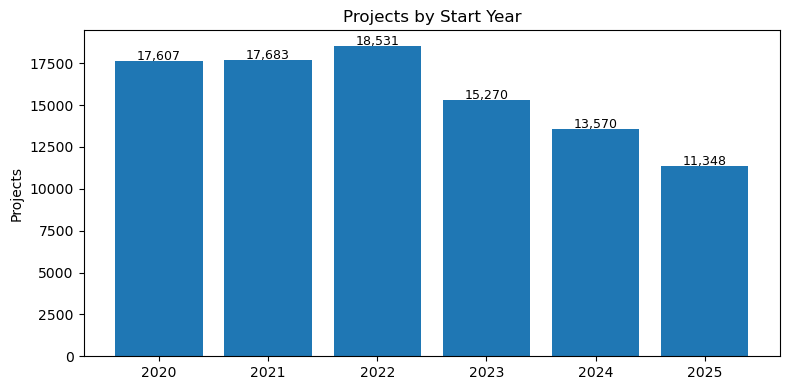

In [12]:
# Projects by year
by_year = df[df['year'].between(2020, 2025)].groupby('year').size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_year.index.astype(str), by_year.values)
ax.set_title('Projects by Start Year')
ax.set_ylabel('Projects')
for i, v in enumerate(by_year.values):
    ax.text(i, v + 80, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

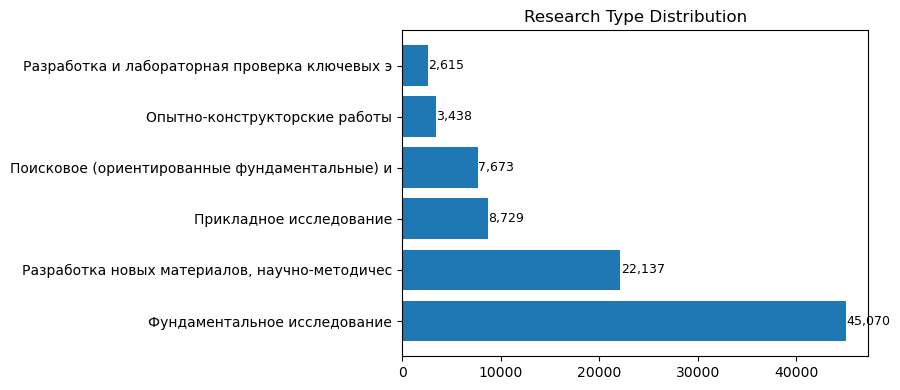

In [13]:
# Research type distribution
types = df['nioktr_types'].value_counts().head(6)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(range(len(types)), types.values)
ax.set_yticks(range(len(types)))
ax.set_yticklabels([t[:45] for t in types.index])
ax.set_title('Research Type Distribution')
for i, v in enumerate(types.values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Projects with budget data : 99,246 (95%)
Total budget              : 3804.3 billion RUB
Median project budget     : 3.5 million RUB
Mean project budget       : 38.3 million RUB


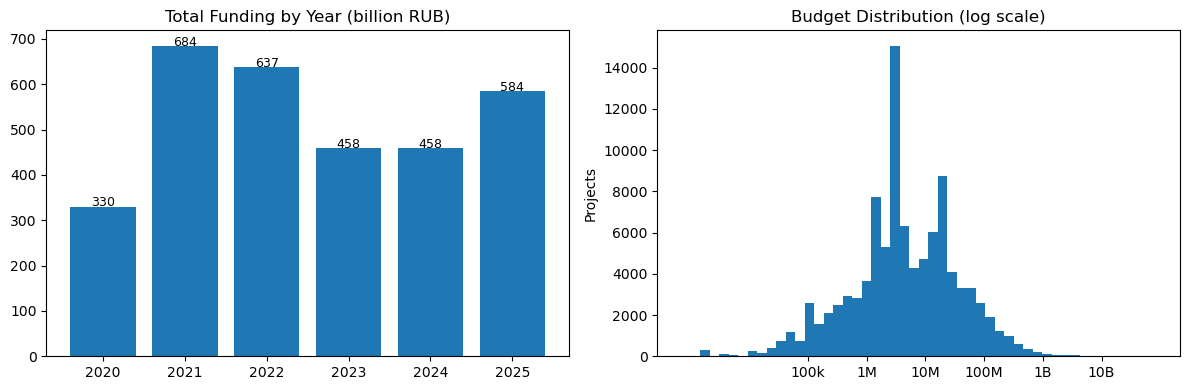

In [14]:
# Budget overview
budget = df['budget_total_thousands'].dropna()
print(f'Projects with budget data : {len(budget):,} ({len(budget)/len(df)*100:.0f}%)')
print(f'Total budget              : {budget.sum()/1_000_000:.1f} billion RUB')
print(f'Median project budget     : {budget.median()/1_000:.1f} million RUB')
print(f'Mean project budget       : {budget.mean()/1_000:.1f} million RUB')

budget_by_year = (
    df[df['year'].between(2020, 2025)]
    .groupby('year')['budget_total_thousands']
    .sum() / 1_000_000
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(budget_by_year.index.astype(str), budget_by_year.values)
axes[0].set_title('Total Funding by Year (billion RUB)')
for i, v in enumerate(budget_by_year.values):
    axes[0].text(i, v + 0.5, f'{v:.0f}', ha='center', fontsize=9)

# Log scale — the distribution is heavily right-skewed
axes[1].hist(np.log10(budget[budget > 0]), bins=50)
axes[1].set_title('Budget Distribution (log scale)')
axes[1].set_xticks([2, 3, 4, 5, 6, 7])
axes[1].set_xticklabels(['100k', '1M', '10M', '100M', '1B', '10B'])
axes[1].set_ylabel('Projects')

plt.tight_layout()
plt.show()

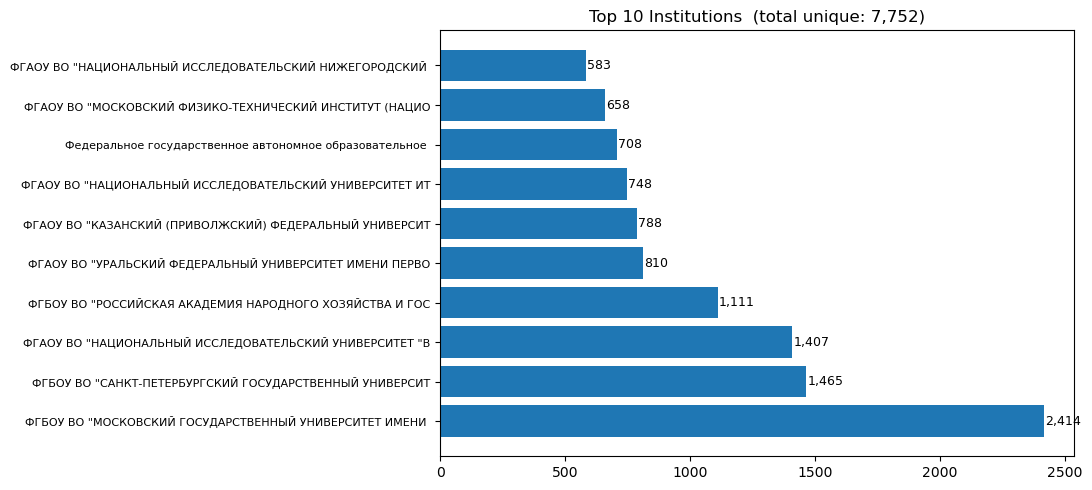

In [15]:
# Top 10 institutions
def shorten(name, n=55):
    return (
        name
        .replace('ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ ОБРАЗОВАТЕЛЬНОЕ УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ', 'ФГБОУ ВО')
        .replace('ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ АВТОНОМНОЕ ОБРАЗОВАТЕЛЬНОЕ УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ', 'ФГАОУ ВО')
        .strip()[:n]
    )

top = df['executor.name'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(range(len(top)), top.values)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([shorten(n) for n in top.index], fontsize=8)
ax.set_title(f'Top 10 Institutions  (total unique: {df["executor.name"].nunique():,})')
for i, v in enumerate(top.values):
    ax.text(v + 5, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

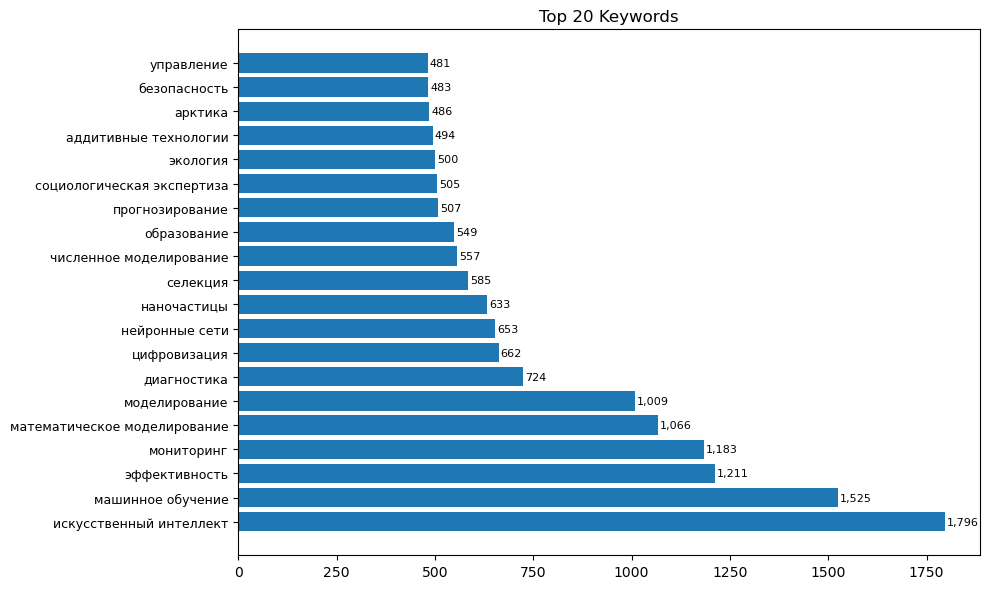

In [16]:
# Top 20 keywords
top_kw = (
    df['keyword_list']
    .dropna()
    .str.split(r'[;,]')
    .explode()
    .str.strip()
    .str.lower()
    .replace('', pd.NA)
    .dropna()
    .value_counts()
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_kw)), top_kw.values)
ax.set_yticks(range(len(top_kw)))
ax.set_yticklabels(top_kw.index, fontsize=9)
ax.set_title('Top 20 Keywords')
for i, v in enumerate(top_kw.values):
    ax.text(v + 5, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Pipeline summary

| Step | Action | Result |
|------|--------|--------|
| Load | 6 JSON files, `pd.json_normalize` | ~112,000 rows, 87 columns |
| Flatten | lists→strings, budgets→sum, stages→count | scalar values only |
| Supervisor | surname + name + patronymic → `supervisor_full_name` | 1 column instead of 3 |
| Drop columns | fill rate <30% + semantic junk | 34 columns remain |
| Deduplicate | `drop_duplicates(keep='last')` on `registration_number` | **104,466 rows** |
| Save | `to_parquet(engine='pyarrow')` | ~180 MB |

**Notable drop:** `scientific_groundwork` — 76% fill, but a large free-text blob. Kept in Parquet, reserved for semantic search (Checkpoint 2).